In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import linalg
from statsmodels.multivariate.pca import PCA
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
fertility = pd.read_csv('data/fertility.csv')
country = pd.read_csv('data/country-indicators.csv')
gender = pd.read_csv('data/gender-data.csv')

# Analysis of Fertility Rates
Alice Zhang

## Abstract
My project explores the decline in fertility rates across select developed nations in the 21st century and seeks to identify its key drivers. To this end, I conduct an in-depth analysis of gender, country, and world development indicators in Python, applying various data science techniques to address my research questions.  

Due to the relatively small dataset, findings may not generalize to all countries. Furthermore, focusing on 2018 data limits our scope and ability to capture temporal trends. Results may also be affected by missing data and unmeasured confounders.

## Introduction

### Background

Over the last 50 years, the global fertility rate has halved. Modernization and technological advancements were coupled with a sharp decline in fertility as population growth surged. This growth was expected to plateau as fertility rates continued to fall. As of 2021, the global fertility rate is 1.66 and [falling](https://www.cbo.gov/publication/58912#:~:text=In%20CBO's%20projections%2C%20the%20total,where%20it%20remains%20through%202053). 

[Current research](https://ourworldindata.org/fertility-rate#data-sources) attribute this decline to factors such as women’s social mobility, economic stability, and improvements in child well-being. 

This project seeks to explore:
* Which factors best predict a country’s fertility rate?
* How do upward mobility, economic prosperity, and child well-being impact fertility rates?
* Which of these explanations are the most probable?

### Motivation

From an economic standpoint, improved welfare is expected to *increase* fertility rates by reducing mortality and improving access to healthcare. Yet, modern societies show the opposite trend.

This begs the question: was fertility simply a matter of scarcity? Or did reproduction hold more value due to limited opportunities for women?

Recent research also suggests that increased social mobility and shifting gender norms may lower fertility. As women gain greater access to education and career opportunities, many choose to delay child-bearing in pursuit of professional goals. 

This project explores how modernization, prosperity, and changing gender roles influence fertility trends in the 21st century.

### Data Sources
The data used in this project are sourced from:
* [United Nations Development Programme](https://www.undp.org/) 
* [World Bank](https://data.worldbank.org/)
* Preprocessed datasets from [lab06](https://github.com/ucsb-ds/pstat100-content/tree/main/labs/lab6-regression/data).

#### Data Description

This project uses data from the Human Development Index (HDI), Gender Development Index (GDI), and World Development Indicators (WDI) to analyze fertility rates across countries. 

Key variables: 
* GDP per capita: Total economic output of a country, adjusted for population size (USD). 
* Immunization rate: Percentage of children vaccinated for DPT and measles. 
* Life expectancy at birth: Average expected lifespan at birth.  
* Expected years of schooling: Average number years of schooling.  
* HDI: Composite index of health, education, and income (GNI) for a country. 
* GDI: Adjusted HDI accounting for gender inequalities.

Detailed technical notes for HDI and GDI can be found [here](https://hdr.undp.org/system/files/documents/technical-notes-calculating-human-development-indices.pdf). Education serves as a proxy for social mobility, reflecting career opportunities and economic status. 

Unemployment data were excluded due to a high proportion of missing values.

#### Variable Description

The variables we'll be exploring include: 

Dataset | Name | Variable | Units
---|---|---|---
`fertility` | `fertility_total` | National fertility rate | Average number of children per woman
`country` | `gdp_percap` | GDP per capita | current U.S. dollars
`country` | `immunization` | Average immunization rate| Percentage (value 1-100)
`country` | `gdi` | Gender development index | Index between 0 and 1 (0 lowest, 1 highest)
`country` | `hdi` | Human development index | Index between 0 and 1 (0 lowest, 1 highest)
`gender` | `edu_expected_yrs_f` | Expected years of education for adult women | Years
`gender` | `life_birthf` | Life expectancy at birth, female (years) | Years


### Project Roadmap
First, I preprocess the data by tidying datasets, extracting relevant variables, and handling missing values. Next, I perform exploratory data analysis, using statistical analysis techniques to assess trends and variability. Then, I build and evaluate a multiple regression model, performing diagnostic tests to ensure valid analysis.

Multiple visualizations are created throughout for impact and clarity. The project concludes with a summary of key findings, limitations, and recommendations for further analysis. 

## Data Tidying

We start by extracting relevant variables from 3 datasets: `fertility`, `gender`, and `country`. 

The datasets are merged on country names, using an inner join for fertility and gender indicators, followed by a left join for country-level data. The final dataset is indexed by country and missing values are removed to ensure completeness. 

Below is a preview of the final dataset (first 4 rows).

In [3]:
# extract variables of interest
fertility_sub = fertility.loc[:, ['Country', 'fertility_total']] 
gender_sub = gender.loc[:, ['educ_expected_yrs_f', 'life_birthf', 'Country']] 
country_sub = country.loc[:, ['Country', 'hdi', 'gdi', 'gdp_percap', 'immunization']]

# merge datasets 
data = pd.merge(    # merge fertility and gender indicators
    fertility_sub,
    gender_sub,
    on = 'Country',    # join on country name (inner join)
    how = 'inner'    
).merge( 
    country_sub,     # merge country indicators (left join)
    on = 'Country', 
    how = 'left'   
).set_index('Country').dropna()  # drop all rows w/ NA's 

data.head(4) # preview the data 

,fertility_total,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
Country,,,,,,,
Afghanistan,4.473,6.795722,66.026,0.509,0.663,493.750418,65.0
Albania,1.617,13.201755,80.167,0.792,0.971,5284.380184,96.5
Algeria,3.023,12.108990,77.938,0.746,0.860,4153.733978,85.5
Angola,5.519,6.973901,63.666,0.582,0.903,3289.646664,56.5


## Exploratory Data Analysis

This section focuses on exploratory data analysis (EDA), applying statistical analysis and data visualization techniques to assess trends and variability.

First, we perform correlation analysis to inspect initial relationships, followed by principal component analysis (PCA) to identify key drivers of variability, then feature analysis to examine individual effects.

### Correlation Analysis

First, we examine the correlation matrix to understand which variables tend to vary together.

The matrix displays pairwise correlations between variables, with values ranging from -1 to 1. A value of 1 indicates a perfect positive relationship, while -1 indicates a perfect negative one. 

These values provide insight into the strength and direction of relationships in our data, helping us identify hidden patterns and potential issues such as multicollinearity.

In [4]:
corr_mx = data.corr()    # create correlation matrix 
corr_mx  # view correlation matrix

,fertility_total,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
fertility_total,1.000000,-0.860730,-0.864710,-0.860446,-0.667698,-0.493784,-0.599602
educ_expected_yrs_f,-0.860730,1.000000,0.828196,0.882125,0.711611,0.518237,0.625988
life_birthf,-0.864710,0.828196,1.000000,0.929450,0.613698,0.626654,0.626974
hdi,-0.860446,0.882125,0.929450,1.000000,0.652496,0.716262,0.579950
gdi,-0.667698,0.711611,0.613698,0.652496,1.000000,0.362602,0.538089
gdp_percap,-0.493784,0.518237,0.626654,0.716262,0.362602,1.000000,0.344651
immunization,-0.599602,0.625988,0.626974,0.579950,0.538089,0.344651,1.000000


Most variables show positive correlations, though their strengths vary.

Key observations: 
* Fertility is negatively correlated with education, life expectancy, and HDI (-0.86).
* Education, life expectancy, and HDI have strong positive correlations (0.83-0.93), indicating they tend to rise together.
* GDP per capita correlates negatively with fertility (-0.49).
* Immunization correlates negatively with fertility (-0.60) and positively (~0.63) with education and life expectancy.
* GDI is moderately negatively correlated with fertility (-0.67).

These patterns suggest possible multicollinearity among features, which may require feature selection or dimensionality reduction in later steps.

Below, I've generated a heatmap to visualize these relationships. 

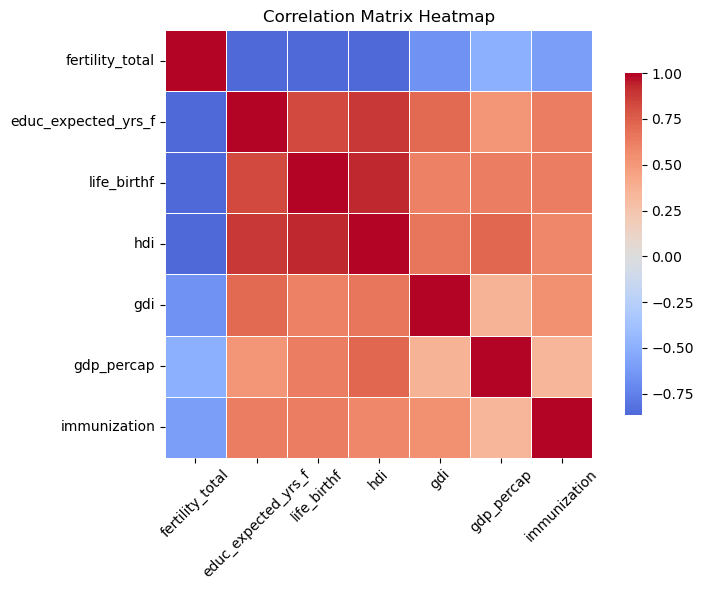

In [5]:
plt.figure(figsize=(8, 6))  # set plot size

sns.heatmap(corr_mx, 
            cmap="coolwarm",      # similar blue-orange color scheme
            center=0,             # center color scale at 0
            square=True,          # make cells square
            linewidths=0.5,       # grid lines between cells
            cbar_kws={"shrink": 0.8})  # color bar size adjustment

plt.title('Correlation Matrix Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Principal Components Analysis

A key preliminary step to data modeling is dimensionality reduction, which helps analyze the dataset to assess its correlation structure and extract insights to inform further analysis.

Principal component analysis (PCA) reduces dimensionality by selecting components that capture the most variance and excluding those with weaker effects. This allows us to simplify the model by focusing on the most important features.

Each principal component (PC) is a linear combination (LC) of the form: 

$$
\text{PC} = \mathbf{Xv} = v_1 \mathbf{x}_1 + v_2 \mathbf{x}_2 + \cdots + v_p \mathbf{x}_p
$$

where 
- **$\mathbf{X}$** is the data matrix.
- **$\mathbf{v}$** is the vector of **loadings**  (weights).

In this section, we apply PCA to identify components that capture the most variation in our dataset, providing insight into its underlying structure to guide further analysis and modeling.

#### Compute Principal Components

The module `multivariate.pca` in `statsmodels` contains an easy implementation for computing PCs. 

Many relevant quantities can be retrieved as attributes, such as `loadings`, `scores`, and `eigenvalues` of the correlation matrix.

In [6]:
# compute principal components
pca = PCA(data, standardize = True)

#### Variance Ratios

Variance ratios quantify the proportion of variation captured by each PC. They are computed from the (normalized) eigenvalues of the correlation matrix, with components ranked in order of descending variance. 

These values help us identify the 'best' (primary) PCs (those capturing the most variability).

In [7]:
var_ratios = pca.eigenvals/pca.eigenvals.sum()  # normalized eigenvalues 
var_ratios  # display

0    0.721384
1    0.108046
2    0.069401
3    0.055937
4    0.021705
5    0.017333
6    0.006194
Name: eigenvals, dtype: float64

In [8]:
print('number selected: ', 1)
print('proportion of variance captured: ', var_ratios[0])

number selected:  1
proportion of variance captured:  0.7213844434872564


The first PC (PC1) captures 72% of total variance, suggesting a dominant pattern where a specific LC of features likely explain fertility rates. The variables with the highest loadings on this component are key drivers of variability. 

This insight informs our next step: identifying *which* features are most influential in driving this primary component. 

#### Inspect Loadings

Now that we've identified the primary PC (PC1), we turn to inspect its loadings. 

Loadings are weights with which each variable contributes to a PC (variable strength). The absolute value of the loading indicates the strength of the relationship, while its sign reflects the direction.

In [9]:
loading_df = pca.loadings.iloc[:, [0]]   # subset loadings for PC1
loading_df = loading_df.rename(columns={'PC1': 'Loading'}) # rename columns
loading_df.head()   # print results 

,comp_0
fertility_total,-0.407364
educ_expected_yrs_f,0.412409
life_birthf,0.416766
hdi,0.425914
gdi,0.340855


PC1 is primarily driven by positive loadings from education, life expectancy, HDI, and GDI.

The negative loading on fertility suggests an inverse relationship, where higher development and education correspond to lower fertility. PC1, therefore, captures a "developmental" axis where more developed countries tend to have lower fertility rates.

It is important to note that PCA captures variability across the entire dataset, not within individual variables. Thus, variables with low (or 0) loadings in the primary PC shouldn’t be immediately excluded from analysis.

### Feature Analysis

Now that we've identified the key drivers of total *variability*, we turn to explore individual feature effects on fertility rates. 

To this end, we will create scatterplots of each feature against fertility rates. This will allow us to visually inspect relationships and provide insight into the key drivers of total *fertility*.

#### Education

The plot shows a negative trend between education and fertility, as expected. The relationship is roughly linear, indicating that higher education levels tend to correlate with lower fertility rates.

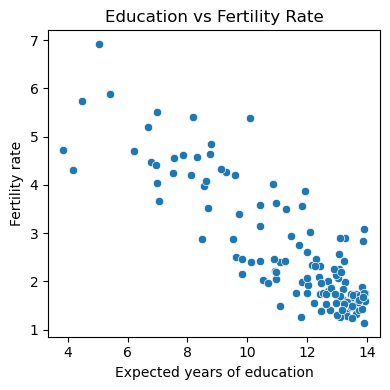

In [10]:
plt.figure(figsize=(4,4))  
sns.scatterplot(data = data, x = "educ_expected_yrs_f", y = "fertility_total")  # create plot 

plt.xlabel("Expected years of education")
plt.ylabel("Fertility rate")
plt.title("Education vs Fertility Rate")
plt.tight_layout()
plt.show()

#### Life Expectancy

There is a similar negative, approximately linear relationship between fertility rates and women’s life expectancy. This aligns with our earlier findings from correlation analysis and PCA.

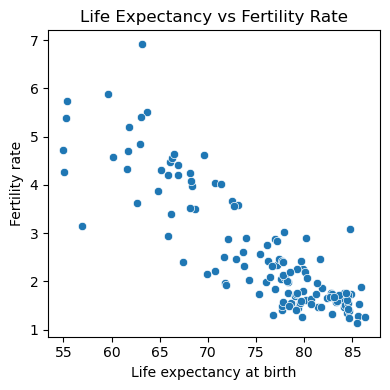

In [11]:
plt.figure(figsize=(4,4)) 
sns.scatterplot(data = data, x = "life_birthf", y = "fertility_total")

plt.xlabel("Life expectancy at birth")
plt.ylabel("Fertility rate")
plt.title("Life Expectancy vs Fertility Rate")
plt.tight_layout()
plt.show()

#### HDI

The plot shows that HDI is associated with lower fertility, though the relationship appears more complex than a simple linear trend. Still, a linear approximation provides a reasonable summary.


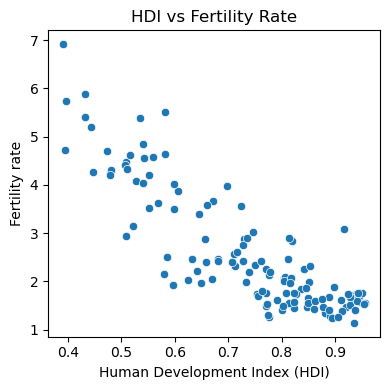

In [12]:
plt.figure(figsize=(4,4))
sns.scatterplot(data = data, x = "hdi", y = "fertility_total")

plt.xlabel("Human Development Index (HDI)")
plt.ylabel("Fertility rate")
plt.title("HDI vs Fertility Rate")
plt.tight_layout()
plt.show()

#### GDI
The plot reveals a negative, non-linear association between GDI and fertility. This suggests that as gender development improves, fertility rates tend to decline, though the relationship isn’t strictly linear. 

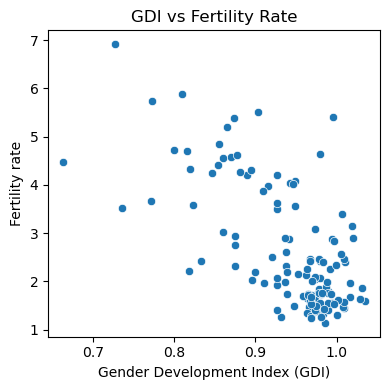

In [13]:
plt.figure(figsize=(4,4))
sns.scatterplot(data = data, x = "gdi", y = "fertility_total")

plt.xlabel("Gender Development Index (GDI)")
plt.ylabel("Fertility rate")
plt.title("GDI vs Fertility Rate")
plt.tight_layout()
plt.show()

#### GDP Per Capita

The pattern resembles a multiplicative inverse or a logarithmic relationship: fertility rates tend to fall as GDP per capita rises, approaching a lower limit of 1. 

The steepest decline occurs in the [0, 40,000] range and slows thereafter, suggesting that fertility rates drop rapidly at lower income levels but stabilize as GDP reaches higher thresholds.

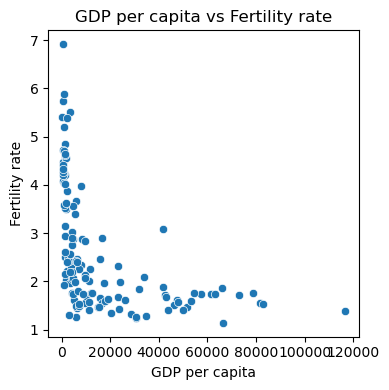

In [14]:
plt.figure(figsize=(4,4))
sns.scatterplot(data = data, x = "gdp_percap", y = "fertility_total")

plt.xlabel("GDP per capita")
plt.ylabel("Fertility rate")
plt.title("GDP per capita vs Fertility rate")
plt.tight_layout()
plt.show()

#### Immunization Rate

The plot shows a negative relationship, though the data is more scattered. Immunization rates mostly cluster between 90 and 100, with fertility rates generally declining as immunization coverage increases.

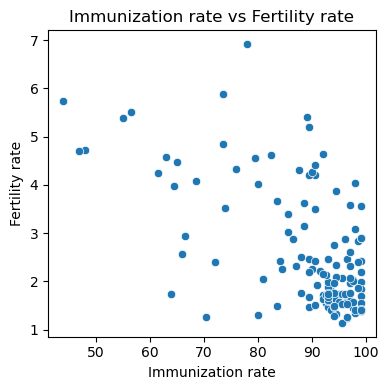

In [15]:
plt.figure(figsize=(4,4))
sns.scatterplot(data = data, x = "immunization", y = "fertility_total")
plt.xlabel("Immunization rate")

plt.ylabel("Fertility rate")
plt.title("Immunization rate vs Fertility rate")
plt.tight_layout()
plt.show()

These visualizations validate our earlier findings, confirming a strong negative relationship between fertility rates and education, life expectancy, HDI, and GDI. Meanwhile, GDP per capita and immunization rates show a more moderate, non-linear negative association.

Now that we have a stronger understanding of feature effects, we can proceed onto modeling.

## Multiple Regression Analysis

First, we will define our model, fit it to the data, then evaluate its performance on multiple evaluation metrics. Then, we perform diagnostics to verify key assumptions before addressing the research questions.

Note that our goal is to *explain* fertility rates, not predict them. Thus, our analysis will focus on interpreting relationships instead of optimizing predictive accuracy. 

### Model Building

First, we standardize the predictors. This will simplify comparison of effect sizes and help us assess how each feature influences fertility rates relative to overall variability. 

The response will be kept in its original units to facilitate interpretation of the results. 

In [25]:
y = data.fertility_total   # create response vector
mat = data.iloc[:,1:7]  # create design matrix 
mat = (mat-mat.mean())/mat.std()   # normalize features 
x = sm.tools.add_constant(mat) # add intercept column (constant 1's)  

x.head() # print first five rows of x

,const,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
Country,,,,,,,
Afghanistan,1.0,-1.863465,-1.174374,-1.440808,-4.090610,-0.724618,-1.974439
Albania,1.0,0.727045,0.596805,0.370722,0.428830,-0.509795,0.656528
Algeria,1.0,0.285146,0.317620,0.076268,-1.199929,-0.560496,-0.262223
Angola,1.0,-1.791412,-1.469967,-0.973523,-0.568968,-0.599243,-2.684383
Argentina,1.0,0.670228,0.558729,0.690780,0.736974,-0.225086,0.113630


### Model Fitting 

Next, we fit the model to our data and evaluate its performance on error metrics such as R-squared, F-statistic, and p-values. These metrics assess model accuracy, generalizability, and overall fit.

In [26]:
mlr = sm.OLS(endog = y, exog = x) # fit model
rslt = mlr.fit() # store result

# extract and print metrics 
print(f"R-squared: {rslt.rsquared:.3f}")
print(f"Adjusted R-squared: {rslt.rsquared_adj:.3f}")
print(f"F-statistic: {rslt.fvalue:.2f}")
print(f"F-statistic p-value: {rslt.f_pvalue:.4f}")

R-squared: 0.825
Adjusted R-squared: 0.816
F-statistic: 95.69
F-statistic p-value: 0.0000


Key metrics: 

* R-squared: 0.825, indicating the model explains 82.5% of the variation in fertility rates. 
* Adjusted R-squared: 0.816, suggests no overfitting.
* F-statistic: 95.69 (p < 0.0001) confirms the model's statistical significance.

The metrics suggest a strong model fit. However, before drawing any conclusions, we must first validate key regression assumptions to ensure valid analysis, which we perform in the next step. 

### Model Diagnostics

This section presents diagnostic tests to verify key regression assumptions of normality, linearity, and constant error variance. To this end, we apply several statistical and data visualization techniques, including: 

* Q-Q plot: Checks normality of residuals for valid inference. 

* Residual plots: Assess linearity and homoscedasticity (constant error variance).

* VIF: Flags multicollinearity (high correlation) among predictors.

#### Normality Check

The Q-Q plot shows an approximately linear pattern with a slightly flatter slope, indicating heavier tails and the presence of extreme values. The slight curvature also suggests mild skewness, though most points align with the reference line.

These deviations are not severe, so the normality assumption holds reasonably well for our model.

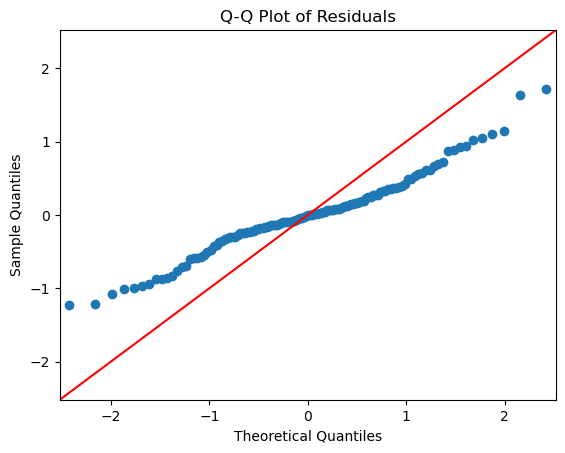

In [18]:
import statsmodels.api as sm
import matplotlib.pyplot as plt 

sm.qqplot(rslt.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

#### Residual Plot

The plot shows a random scatter with no apparent pattern, supporting the homoscedasticity (constant error variance) assumption. A slight clustering around a fitted value of 1 may warrant further investigation but does not indicate a serious violation.

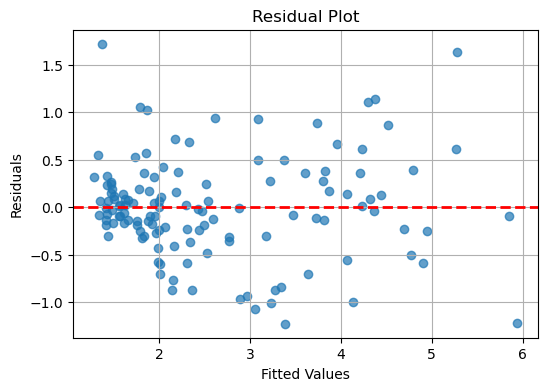

In [27]:
# create dataframe 
df = pd.DataFrame({
    'fitted_values': rslt.fittedvalues,  # get fitted values
    'residuals': rslt.resid  # get residuals
})

plt.figure(figsize=(6, 4))    # set plot size 
plt.scatter(df['fitted_values'], df['residuals'], alpha=0.7)    # create residual plot 
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Fitted Values'); plt.ylabel('Residuals')

plt.grid(True); plt.show()  # display 

#### Variance Inflation Factor (VIF)

Multicollinearity (high correlation among features) can lead to unstable coefficient estimates and hinder model interpretability. Recall that PCA suggested this may present in our data. 

The VIF is used to quantify multicollinearity, with a common threshold of 10. High VIF values can inflate the significance of predictors and distort true feature effects.

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# compute the VIF for each feature in the design matrix x
vif_data = pd.DataFrame()
vif_data['Feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

print(vif_data)   # display VIF values

               Feature        VIF
0                const   1.000000
1  educ_expected_yrs_f   6.084975
2          life_birthf   8.242011
3                  hdi  15.629728
4                  gdi   2.111264
5           gdp_percap   2.398091
6         immunization   1.863205


The results show that `hdi`, `life_birthf`, and `educ_expected_yrs_f` have high VIF scores ranging from 6 to 15, while other variables have moderate to low VIFs. 

##### How should we proceed?

First, let's summarize our findings:

* HDI, education, and life expectancy are highly correlated (0.83-0.93), suggesting that these variables may capture similar underlying information.

* These features have high VIF scores that suggest problematic multicollinearity. 

The logical next step is to remove `hdi` from the model. As a composite index of health, education, and standard of living, `hdi` overlaps with several other predictors. 

Thus, removing it will reduce multicollinearity while preserving most information, resulting in a simpler, more interpretable model.

### Model Refinement

First, we will remove `hdi` and recheck VIF to confirm the issue is resolved. Then, we will build a new OLS model using the remaining predictors, evaluate its performance, and address our research questions based on the results.

In [29]:
# create new design matrix with hdi removed  
dm = data.iloc[:, 1:7]
dm = dm.drop(columns=['hdi'])   # drop hdi 

# normalize features 
dm = (dm - dm.mean()) / dm.std()
X = sm.tools.add_constant(dm)  # add intercept column (constant 1's)

print(X.columns)   # validate hdi has been removed 

Index(['const', 'educ_expected_yrs_f', 'life_birthf', 'gdi', 'gdp_percap',
       'immunization'],
      dtype='object')


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# recheck VIF 
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# display the VIF values
print(vif_data)

               Feature       VIF
0                const  1.000000
1  educ_expected_yrs_f  4.133657
2          life_birthf  4.113814
3                  gdi  2.087899
4           gdp_percap  1.658830
5         immunization  1.808400


The issue appears to be resolved: with VIF values all ranging between 1-4, the features no longer exhibit multicollinearity. We can now proceed onto the next step: building a new OLS model. 

Again, the predictors will be standardized with the response in its original units. 

In [23]:
# fit the OLS model
model = sm.OLS(endog=y, exog=X)   # using original response variable y

# store the result
results = model.fit()

# print evaluation metrics
print(f"R-squared: {results.rsquared:.3f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.3f}")
print(f"F-statistic: {results.fvalue:.2f}")
print(f"F-statistic p-value: {results.f_pvalue:.4f}")

R-squared: 0.822
Adjusted R-squared: 0.814
F-statistic: 113.28
F-statistic p-value: 0.0000


Key metrics:

* The R-squared value of 0.822 is very close to our old model (0.825), indicating that removing `hdi` had minimal impact on predictive power.
* A strong adjusted R-squared (0.814) indicates no overfitting. 
* The F-statistic increased to 113.28 (vs. 95.69), suggesting  an overall stronger fit.

Overall, removing `hdi` improved the model by reducing complexity while preserving accuracy. 

## Research Questions 

Now, we turn to address our research questions based on the OLS results. Namely: 

* Which factors best predict a country’s fertility rate?
* How do upward mobility, economic prosperity, and child well-being impact fertility rates?
* Which of these explanations are the most probable?

#### Model Results

Recall that the predictors were standardized, while the response was not. This means the coefficients represent the expected change in fertility rate (in original units) for a 1 standard deviation (SD) increase in each predictor.

The intercept reflects the expected fertility rate when all predictors are at their baseline (mean) values, expressed in the original units of fertility.

Keeping those notes in mind, let's analyze the OLS summary. 

In [24]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        fertility_total   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     113.3
Date:                Wed, 04 Jun 2025   Prob (F-statistic):           2.57e-44
Time:                        14:13:35   Log-Likelihood:                -101.54
No. Observations:                 129   AIC:                             215.1
Df Residuals:                     123   BIC:                             232.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.6042    

A larger magnitude of coefficients suggests a stronger association with fertility rates, while larger t-values (and smaller p-values) indicate statistical significance.


Interpretation: 

* The intercept (2.6042) represents the expected fertility rate when all predictors are at their mean values, ~2.6 children per woman.
* A 1 SD increase in female education reduces fertility by 0.5132 units.
* A 1 SD increase in life expectancy reduces fertility by 0.6648 units.
* GDI, GDP per capita, and immunization show weak associations with fertility rates and are not statistically significant (p > 0.05).

Key findings: 

* The strongest predictors are education and life expectancy, both are statistically significant (p < 0.05). They are negatively correlated with fertility, which supports the child well-being argument 
* Other predictors, such as GDI, GDP per capita, and immunization exhibit weak relationships and lack predictive power. 

#### Which factors best predict a country’s fertility rate? 

The strongest predictors of a country’s fertility rate are female education and life expectancy. Higher female education likely leads to lower fertility through delayed childbearing, increased career opportunities, and better access to family planning. 

Longer life expectancy also aligns with lower fertility, supporting the child well-being argument, where parents in healthier countries invest more resources in fewer children. 

#### How do upward mobility, economic prosperity, and child well-being impact fertility rates?

Upward mobility (proxied by education) is linked to lower fertility through delayed childbearing. 

Economic prosperity (GDP, GDI) show weak associations, suggesting that factors like income distribution or social safety nets may be more influential than GDP alone.

Child well-being (proxied by life expectancy) negatively correlates with fertility, supporting the idea that better health outcomes lead to lower fertility as families focus on quality over quantity.

#### Which explanations are most probable?

Education and life expectancy stand out as the most likely explanations for fertility variation. Education captures upward mobility and delayed childbearing, while life expectancy reflects child well-being. 

GDP per capita has minimal impact, though GDI’s moderate role suggests gender development also influences fertility decisions.

## Conclusion

This project examined the decline in fertility rates across select developed nations using data from 2018. 

Due to the relatively small dataset and presence of unrelated features, we first cleaned the data and performed exploratory analysis to uncover hidden trends. Variation was assessed through correlation analysis and PCA, followed by the development, evaluation, and refinement of a multiple regression model.

Our analysis revealed that both improvements in well-being and social mobility for women are negatively associated with fertility rates.

Limitations include data size, noise sensitivity, and focus on a single year, which limited the scope of our analysis. Future work could include additional variables and apply more robust models, such as time-series, to better capture temporal trends.